In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
# lectura del documento 
df = pd.read_excel('./data/online_retail_II.xlsx')
# seleccionar solo reino unido 
df = df[df['Country']=='United Kingdom']
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


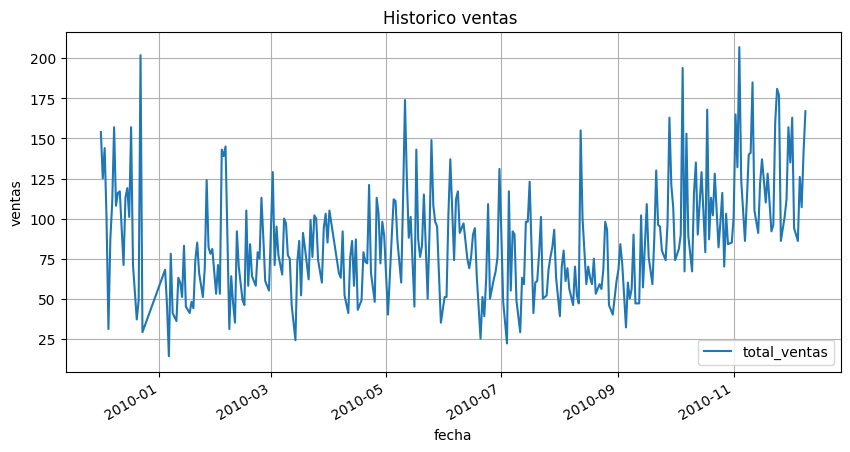

In [4]:
# Que hacer? 
# 1. Necesitamos hacer un forecast de ventas para eso usaremos Invoice para obtener el total de ventas al dia en un supermercado 

# normalizar la fecha 
df['norm_date'] = df['InvoiceDate'].dt.normalize()

ventas = df[['Invoice','norm_date']].drop_duplicates(subset='Invoice').reset_index(drop=True)

# contar por fecha la cantidad de ventas 
ventas = ventas.groupby('norm_date').agg(
    total_ventas = ('Invoice','count')
).reset_index()

# plotear
_ = ventas.set_index('norm_date')
_.plot(figsize=(10,5))
plt.grid()
plt.title('Historico ventas ')
plt.xlabel('fecha')
plt.ylabel('ventas')
plt.show()

In [5]:
# revisar la estacionalidad 


In [6]:
# generar nuevas variables a partir de la fecha y aplicar xgboost
ventas['dia_semana'] = ventas['norm_date'].dt.dayofweek
ventas['dia_mes'] = ventas['norm_date'].dt.day
ventas['dia_ano'] = ventas['norm_date'].dt.dayofyear
ventas['mes'] = ventas['norm_date'].dt.month
ventas['estacion'] = ventas['norm_date'].dt.quarter
ventas['anio'] = ventas['norm_date'].dt.year

# variables ciclicas
# dias
ventas['dia_semana_sin'] = np.sin(2 * np.pi * ventas['dia_semana'] / 7)
ventas['dia_semana_cos'] = np.cos(2 * np.pi * ventas['dia_semana'] / 7)

# meses
ventas['mes_sin'] = np.sin(2 * np.pi * (ventas['mes'] - 1)/12)
ventas['mes_con'] = np.cos(2 * np.pi * (ventas['mes'] - 1)/12)

# definir si es dia se semana o no 
ventas['f_semana'] = ventas['dia_semana'].isin([5,6]).astype(int)

# lags
ventas['lag_1'] = ventas['total_ventas'].shift(1)
ventas['lag_3'] = ventas['total_ventas'].shift(3)
ventas['lag_6'] = ventas['total_ventas'].shift(6)

# eliminar las columnas con lag 
ventas = ventas.dropna(subset=['lag_6'])

ventas

,norm_date,total_ventas,dia_semana,dia_mes,dia_ano,mes,estacion,anio,dia_semana_sin,dia_semana_cos,mes_sin,mes_con,f_semana,lag_1,lag_3,lag_6
6,2009-12-07,110,0,7,341,12,4,2009,0.000000,1.000000,-0.5,0.866025,0,87.0,100.0,154.0
7,2009-12-08,157,1,8,342,12,4,2009,0.781831,0.623490,-0.5,0.866025,0,110.0,31.0,125.0
8,2009-12-09,108,2,9,343,12,4,2009,0.974928,-0.222521,-0.5,0.866025,0,157.0,87.0,144.0
9,2009-12-10,116,3,10,344,12,4,2009,0.433884,-0.900969,-0.5,0.866025,0,108.0,110.0,100.0
10,2009-12-11,117,4,11,345,12,4,2009,-0.433884,-0.900969,-0.5,0.866025,0,116.0,157.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,2010-12-05,86,6,5,339,12,4,2010,-0.781831,0.623490,-0.5,0.866025,1,94.0,135.0,101.0
303,2010-12-06,126,0,6,340,12,4,2010,0.000000,1.000000,-0.5,0.866025,0,86.0,163.0,112.0
304,2010-12-07,107,1,7,341,12,4,2010,0.781831,0.623490,-0.5,0.866025,0,126.0,94.0,157.0
305,2010-12-08,141,2,8,342,12,4,2010,0.974928,-0.222521,-0.5,0.866025,0,107.0,86.0,135.0


In [11]:
# aplicar modelo 
import xgboost 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X = ventas.drop(['norm_date','total_ventas'],axis=1)
y = ventas['total_ventas']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

model = xgboost.XGBRegressor().fit(X_train,y_train)
predict = model.predict(X_test)

# resultados metricas
rmse = mean_squared_error(y_test,predict)**0.5
rmse

19.98376492545144

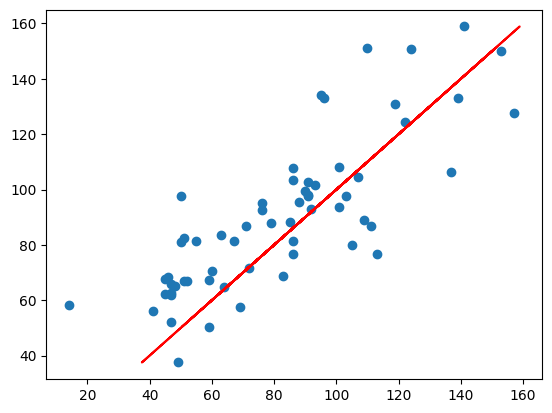

In [12]:
# plot resultados 
plt.scatter(x=y_test,y=predict)
plt.plot(predict,predict,c='r')

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

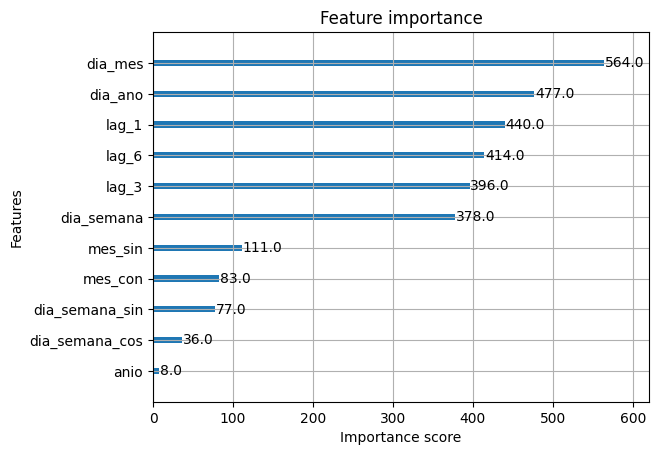

In [13]:
# variables importantes 
xgboost.plot_importance(model)

In [18]:
X_test['real'] = y_test
X_test['predict'] = predict

X_test

,dia_semana,dia_mes,dia_ano,mes,estacion,anio,dia_semana_sin,dia_semana_cos,mes_sin,mes_con,f_semana,lag_1,lag_3,lag_6,real,predict
183,6,18,199,7,3,2010,-0.781831,0.623490,1.224647e-16,-1.000000,1,123.0,98.0,29.0,41,55.976143
295,4,26,330,11,4,2010,-0.433884,-0.900969,-8.660254e-01,0.500000,0,177.0,160.0,128.0,86,103.285103
234,3,16,259,9,3,2010,0.433884,-0.900969,-8.660254e-01,-0.500000,0,83.0,102.0,90.0,109,89.106842
204,2,11,223,8,3,2010,0.974928,-0.222521,-5.000000e-01,-0.866025,0,52.0,46.0,61.0,47,65.681984
66,3,25,56,2,1,2010,0.433884,-0.900969,5.000000e-01,0.866025,0,113.0,79.0,84.0,88,95.509178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,3,23,266,9,3,2010,0.433884,-0.900969,-8.660254e-01,-0.500000,0,96.0,88.0,109.0,95,134.216644
302,6,5,339,12,4,2010,-0.781831,0.623490,-5.000000e-01,0.866025,1,94.0,135.0,101.0,86,107.793411
287,2,17,321,11,4,2010,0.974928,-0.222521,-8.660254e-01,0.500000,0,137.0,91.0,141.0,124,150.635681
291,0,22,326,11,4,2010,0.000000,1.000000,-8.660254e-01,0.500000,0,92.0,110.0,122.0,96,133.102875


(array([ 4.,  3.,  3., 17., 11.,  7.,  7.,  3.,  3.,  3.]),
 array([-47.49838257, -39.13488922, -30.77139587, -22.40790253,
        -14.04440918,  -5.68091583,   2.68257751,  11.04607086,
         19.40956421,  27.77305756,  36.1365509 ]),
 <BarContainer object of 10 artists>)

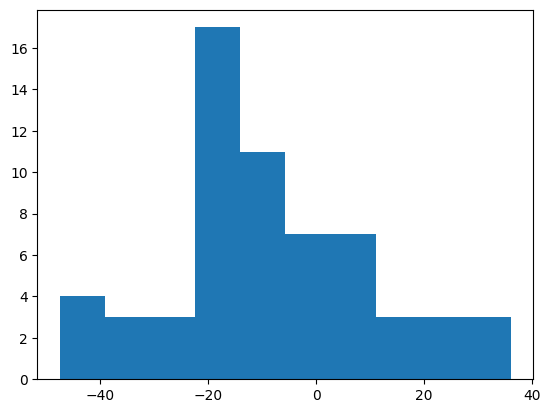

In [19]:
diff = X_test['real'] - X_test['predict']

plt.hist(diff)